In [5]:
import pandas as pd
import numpy as np

# 재현성을 위해 시드 고정
np.random.seed(42)

def generate_params(n):
    """지정된 행(n) 개수만큼 파라미터 조건에 맞춰 데이터를 생성하는 함수"""

    # param1: 400~700, 70%는 500, 30%는 랜덤 (단, 몇몇은 같은 수를 가져야 함)
    p1_pool = np.random.randint(400, 701, size=20)
    p1_random = np.random.choice(p1_pool, n)
    p1 = np.where(np.random.rand(n) < 0.70, 500, p1_random)

    # param2: 10~20 랜덤
    p2 = np.random.randint(10, 21, n)

    # param3: 500~1000, 90%는 700
    p3 = np.where(np.random.rand(n) < 0.90, 700, np.random.randint(500, 1001, n))

    # param4: 0~20, 95%는 15
    p4 = np.where(np.random.rand(n) < 0.95, 15, np.random.randint(0, 21, n))

    # param5: 100~300, 80%는 250
    p5 = np.where(np.random.rand(n) < 0.80, 250, np.random.randint(100, 301, n))

    # param6: 30~70, 90%는 50
    p6 = np.where(np.random.rand(n) < 0.90, 50, np.random.randint(30, 71, n))

    # param7: 0~20, 90%는 0, 10%는 0~20 랜덤
    p7 = np.where(np.random.rand(n) < 0.90, 0, np.random.randint(0, 21, n))

    # param8: 20~30, 90%는 0, 10%는 20~30 랜덤
    p8 = np.where(np.random.rand(n) < 0.90, 0, np.random.randint(20, 31, n))

    # param9, 10, 11: 20~35, 80%는 25, 20%는 20~35 랜덤 (세 컬럼은 서로 같은 값)
    p9 = np.where(np.random.rand(n) < 0.80, 25, np.random.randint(20, 36, n))
    p10 = p9.copy()
    p11 = p9.copy()

    # param12: 20~35 랜덤
    p12 = np.random.randint(20, 36, n)

    # param13, 14: 합이 100. 80%는 (50, 50), 20%는 최소 20 최대 80 랜덤
    p13_random = np.random.randint(20, 81, n)
    p13 = np.where(np.random.rand(n) < 0.80, 50, p13_random)
    p14 = 100 - p13

    return {
        'param1': p1, 'param2': p2, 'param3': p3, 'param4': p4,
        'param5': p5, 'param6': p6, 'param7': p7, 'param8': p8,
        'param9': p9, 'param10': p10, 'param11': p11, 'param12': p12,
        'param13': p13, 'param14': p14
    }

# ---------------------------------------------------------
# 1. Base 데이터셋 5000개 생성 (ppid1 ~ ppid5000)
# ---------------------------------------------------------
base_ppid_count = 5000
# ppid당 step 갯수를 1~10개 사이로 랜덤 배정
step_counts = np.random.randint(1, 11, base_ppid_count)

ppids = []
ppid_steps = []
for i, count in enumerate(step_counts, 1):
    ppids.extend([f'ppid{i}'] * count)
    ppid_steps.extend([f'ppid_step{j}' for j in range(1, count + 1)])

df_base = pd.DataFrame({'ppid': ppids, 'ppid_step': ppid_steps})
params_df = pd.DataFrame(generate_params(len(df_base)))
df_base = pd.concat([df_base, params_df], axis=1)

# ---------------------------------------------------------
# 2. 증강(Augmentation) 데이터 생성 함수
# ---------------------------------------------------------
def create_augmented_data(base_df, action, num_samples, start_idx):
    """
    원본 데이터에서 랜덤하게 샘플링하여 행을 추가하거나 삭제하는 함수
    """
    augmented_rows = []
    curr_idx = start_idx

    grouped = base_df.groupby('ppid')

    # 안전장치: 삭제 시 최소 1개는 남도록 필터링
    if action == 'sub1':
        valid_ppids = [p for p, group in grouped if len(group) > 1]
    elif action == 'sub2':
        valid_ppids = [p for p, group in grouped if len(group) > 2]
    else:
        valid_ppids = list(grouped.groups.keys())

    # 지정된 수만큼 랜덤 샘플링 (비복원)
    selected_ppids = np.random.choice(valid_ppids, num_samples, replace=False)

    for ppid in selected_ppids:
        group = grouped.get_group(ppid).copy()
        new_ppid_name = f'ppid{curr_idx}'

        if action == 'sub1':
            drop_idx = np.random.choice(group.index)
            group = group.drop(drop_idx)

        elif action == 'sub2':
            drop_indices = np.random.choice(group.index, 2, replace=False)
            group = group.drop(drop_indices)

        elif action == 'add1':
            new_param_row = pd.DataFrame(generate_params(1))
            new_row = pd.concat([pd.DataFrame({'ppid': [ppid], 'ppid_step': ['temp']}), new_param_row], axis=1)
            group = pd.concat([group, new_row], ignore_index=True)

        elif action == 'add2':
            new_param_rows = pd.DataFrame(generate_params(2))
            new_rows_df = pd.concat([pd.DataFrame({'ppid': [ppid]*2, 'ppid_step': ['temp']*2}), new_param_rows], axis=1)
            group = pd.concat([group, new_rows_df], ignore_index=True)

        # 신규 ppid 할당 및 step 재정렬
        group['ppid'] = new_ppid_name
        group['ppid_step'] = [f'ppid_step{i}' for i in range(1, len(group) + 1)]

        augmented_rows.append(group)
        curr_idx += 1

    return pd.concat(augmented_rows, ignore_index=True), curr_idx

# ---------------------------------------------------------
# 3. 변형 파이프라인 실행
# ---------------------------------------------------------
next_idx = 5001

# 1) 500개: ppid_step 1개 지운 신규 데이터 (ppid5001 ~ ppid5500)
df_sub1, next_idx = create_augmented_data(df_base, 'sub1', 500, next_idx)

# 2) 500개: ppid_step 1개 추가한 신규 데이터 (ppid5501 ~ ppid6000)
df_add1, next_idx = create_augmented_data(df_base, 'add1', 500, next_idx)

# 3) 400개: ppid_step 2개 추가한 신규 데이터 (ppid6001 ~ ppid6400)
df_add2, next_idx = create_augmented_data(df_base, 'add2', 400, next_idx)

# 4) 200개: ppid_step 2개 지운 신규 데이터 (ppid6401 ~ ppid6600)
df_sub2, next_idx = create_augmented_data(df_base, 'sub2', 200, next_idx)

# ---------------------------------------------------------
# 4. 최종 데이터셋 결합
# ---------------------------------------------------------
final_df = pd.concat([df_base, df_sub1, df_add1, df_add2, df_sub2], ignore_index=True)

# 확인 출력
print(f"최종 생성된 DataFrame의 형태: {final_df.shape}")
print(f"총 고유 ppid 갯수: {final_df['ppid'].nunique()} 개 (예상: 6600개)")
display(final_df.head(10))

최종 생성된 DataFrame의 형태: (36963, 16)
총 고유 ppid 갯수: 6600 개 (예상: 6600개)


,ppid,ppid_step,param1,param2,param3,param4,param5,param6,param7,param8,param9,param10,param11,param12,param13,param14
0,ppid1,ppid_step1,500,14,700,15,250,50,0,0,25,25,25,35,60,40
1,ppid1,ppid_step2,421,20,700,15,250,50,0,0,34,34,34,35,50,50
2,ppid1,ppid_step3,500,15,700,15,188,50,0,0,25,25,25,21,50,50
3,ppid1,ppid_step4,500,13,700,15,250,50,0,0,25,25,25,25,50,50
4,ppid1,ppid_step5,680,13,700,15,250,50,0,0,25,25,25,35,50,50
5,ppid1,ppid_step6,500,13,700,15,250,38,0,0,29,29,29,29,50,50
6,ppid1,ppid_step7,620,12,853,15,250,50,0,0,25,25,25,33,50,50
7,ppid2,ppid_step1,620,19,728,15,250,50,0,0,25,25,25,29,50,50
8,ppid2,ppid_step2,426,14,700,15,250,50,0,0,29,29,29,23,50,50
9,ppid2,ppid_step3,500,15,700,15,250,50,0,0,25,25,25,26,50,50


In [7]:
pd.unique(final_df.param8)

array([ 0, 29, 21, 30, 20, 27, 25, 22, 26, 24, 23, 28])

In [10]:
final_df.to_csv('recipe_raw_data_virtual.csv')

In [11]:
import os
print(os.listdir('.'))

['.config', 'recipe_raw_data_virtual.csv', 'recipe_raw_data_virtual.xlsx', 'sample_data']


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
# Google Drive 내에 저장할 경로를 지정합니다.
# 예시: 'My Drive/Colab Notebooks/recipe_raw_data_virtual_drive.csv'
# 'My Drive'는 Google Drive의 최상위 폴더를 나타냅니다.
# Colab Notebooks 폴더가 없으면 자동으로 생성됩니다.
save_path = '/content/drive/MyDrive/python/Recipe_clustering/recipe_raw_data_virtual_drive.csv'

# DataFrame을 CSV 파일로 저장합니다.
final_df.to_csv(save_path, index=False)

print(f"CSV 파일이 다음 경로에 저장되었습니다: {save_path}")

CSV 파일이 다음 경로에 저장되었습니다: /content/drive/MyDrive/python/Recipe_clustering/recipe_raw_data_virtual_drive.csv


In [19]:
df = final_df.copy()

In [20]:
# ppid와 ppid_step을 결합한 새로운 컬럼 생성
df['ppid_full_step'] = df['ppid'] + '_' + df['ppid_step']

# 결과 확인 (새로 만든 컬럼을 맨 앞으로 이동시켜서 보여줍니다)
cols = ['ppid_full_step'] + [c for c in df.columns if c != 'ppid_full_step']
df = df[cols]

display(df.head(10))

,ppid_full_step,ppid,ppid_step,param1,param2,param3,param4,param5,param6,param7,param8,param9,param10,param11,param12,param13,param14
0,ppid1_ppid_step1,ppid1,ppid_step1,500,14,700,15,250,50,0,0,25,25,25,35,60,40
1,ppid1_ppid_step2,ppid1,ppid_step2,421,20,700,15,250,50,0,0,34,34,34,35,50,50
2,ppid1_ppid_step3,ppid1,ppid_step3,500,15,700,15,188,50,0,0,25,25,25,21,50,50
3,ppid1_ppid_step4,ppid1,ppid_step4,500,13,700,15,250,50,0,0,25,25,25,25,50,50
4,ppid1_ppid_step5,ppid1,ppid_step5,680,13,700,15,250,50,0,0,25,25,25,35,50,50
5,ppid1_ppid_step6,ppid1,ppid_step6,500,13,700,15,250,38,0,0,29,29,29,29,50,50
6,ppid1_ppid_step7,ppid1,ppid_step7,620,12,853,15,250,50,0,0,25,25,25,33,50,50
7,ppid2_ppid_step1,ppid2,ppid_step1,620,19,728,15,250,50,0,0,25,25,25,29,50,50
8,ppid2_ppid_step2,ppid2,ppid_step2,426,14,700,15,250,50,0,0,29,29,29,23,50,50
9,ppid2_ppid_step3,ppid2,ppid_step3,500,15,700,15,250,50,0,0,25,25,25,26,50,50


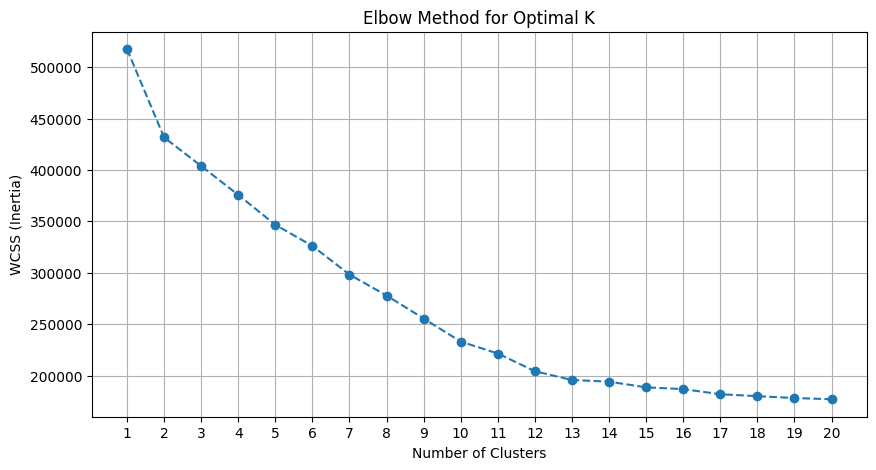

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 특징 선택 및 스케일링
features = ['param1', 'param2', 'param3','param4','param5','param6','param7',
            'param8','param9','param10','param11','param12','param13','param14']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 엘보우 방법을 통한 최적의 K 탐색 (최대 20개까지)
wcss = []
max_k = min(20, df['ppid'].nunique())

for i in range(1, max_k + 1):
    kmeans_test = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans_test.fit(X_scaled)
    wcss.append(kmeans_test.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

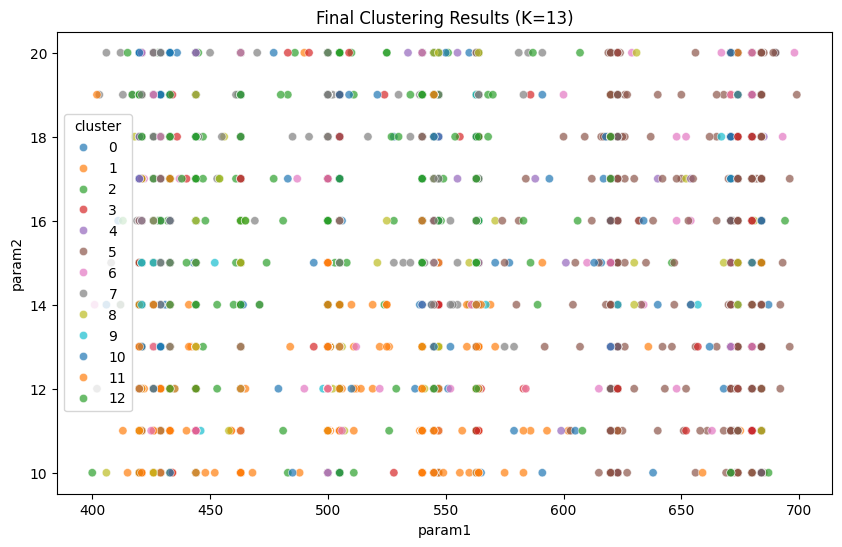

,ppid_full_step,ppid,ppid_step,param1,param2,param3,param4,param5,param6,param7,param8,param9,param10,param11,param12,param13,param14,cluster
36938,ppid6594_ppid_step5,ppid6594,ppid_step5,680,15,700,15,250,50,0,23,25,25,25,22,50,50,0
36937,ppid6594_ppid_step4,ppid6594,ppid_step4,671,20,700,15,257,50,0,22,25,25,25,21,50,50,0
25,ppid5_ppid_step2,ppid5,ppid_step2,500,12,700,15,250,50,0,29,25,25,25,24,50,50,0
33862,ppid6107_ppid_step6,ppid6107,ppid_step6,500,17,700,15,250,50,0,20,25,25,25,25,50,50,0
33860,ppid6107_ppid_step4,ppid6107,ppid_step4,429,17,700,15,250,50,0,20,25,25,25,35,50,50,0
33859,ppid6107_ppid_step3,ppid6107,ppid_step3,500,16,700,15,250,50,0,26,25,25,25,24,50,50,0
33857,ppid6107_ppid_step1,ppid6107,ppid_step1,500,19,700,15,250,50,0,22,25,25,25,25,50,50,0
2716,ppid501_ppid_step2,ppid501,ppid_step2,671,17,700,15,250,50,0,23,25,25,25,30,50,50,0
33812,ppid6101_ppid_step1,ppid6101,ppid_step1,500,16,700,15,250,50,0,28,25,25,25,33,50,50,0
33838,ppid6105_ppid_step3,ppid6105,ppid_step3,500,20,700,15,250,50,0,21,29,29,29,21,37,63,0


In [30]:
# 3. 최종 클러스터링 수행 (예시로 5개 설정, 위 그래프를 보고 조정 가능합니다)
optimal_k = 13
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# 4. 결과 시각화 및 데이터 확인
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='param1', y='param2', hue='cluster', palette='tab10', alpha=0.7)
plt.title(f'Final Clustering Results (K={optimal_k})')
plt.show()

display(df.sort_values('cluster').head(15))

In [24]:
# !pip install kneed

자동으로 탐색된 최적의 클러스터 개수(K): 4

[클러스터별 주요 특징 요약]


,param1,param2,param3,count
cluster,,,,
0,496.888048,12.491970,696.717444,17186
1,496.965088,18.014836,696.932013,14694
2,660.800323,15.082885,699.266954,3716
3,515.667886,14.952451,908.700805,1367


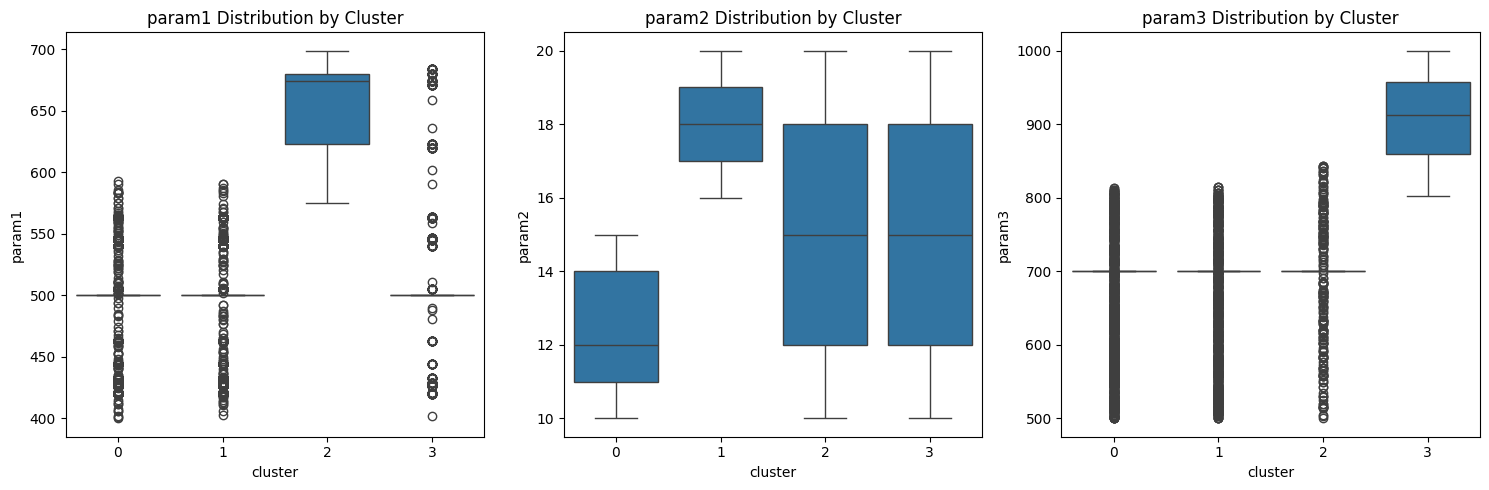

In [25]:
from kneed import KneeLocator

# 1. 최적의 K 자동 탐색 (Knee Point 찾기)
kn = KneeLocator(range(1, max_k + 1), wcss, curve='convex', direction='decreasing')
auto_k = kn.knee
print(f'자동으로 탐색된 최적의 클러스터 개수(K): {auto_k}')

# 2. 최적화된 K로 클러스터링 수행
kmeans_final = KMeans(n_clusters=auto_k, random_state=42, n_init='auto')
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# 3. 클러스터별 특징 요약 (Mean value analysis)
cluster_summary = df.groupby('cluster')[features].mean()
cluster_summary['count'] = df.groupby('cluster').size()

print('\n[클러스터별 주요 특징 요약]')
display(cluster_summary)

# 4. 특징 시각화 (Boxplot을 통한 분포 차이 확인)
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='cluster', y=feature, data=df)
    plt.title(f'{feature} Distribution by Cluster')
plt.tight_layout()
plt.show()

In [28]:
cluster_summary

,param1,param2,param3,count
cluster,,,,
0,496.888048,12.491970,696.717444,17186
1,496.965088,18.014836,696.932013,14694
2,660.800323,15.082885,699.266954,3716
3,515.667886,14.952451,908.700805,1367
